In [ ]:



#TASK 1




     |████████████████████████████████| 489.7 MB 10 kB/s  eta 0:00:012    |██▏                             | 33.3 MB 14.4 MB/s eta 0:00:32     |█████████████████████           | 320.3 MB 1.6 MB/s eta 0:01:44     |█████████████████████████▍      | 388.3 MB 14.3 MB/s eta 0:00:08     |███████████████████████████▍    | 418.9 MB 1.5 MB/s eta 0:00:47     |█████████████████████████████   | 442.6 MB 6.6 MB/s eta 0:00:08
     |████████████████████████████████| 463 kB 7.0 MB/s eta 0:00:01
     |████████████████████████████████| 5.1 MB 4.9 MB/s eta 0:00:01
     |████████████████████████████████| 5.5 MB 13.3 MB/s eta 0:00:01
     |████████████████████████████████| 24.5 MB 2.8 MB/s eta 0:00:01
     |████████████████████████████████| 1.3 MB 5.3 MB/s eta 0:00:01
     |████████████████████████████████| 316 kB 3.9 MB/s eta 0:00:01
     |████████████████████████████████| 6.6 MB 10.9 MB/s eta 0:00:01
     |████████████████████████████████| 5.9 MB 5.3 MB/s eta 0:00:01
  Attempting uninstall: tensorboard-d

In [ ]:
#PACKAGE VERSION CONTROL
!pip install --upgrade tensorflow==2.7
!pip install --upgrade protobuf==3.20
#import tensorflow as tf
#tf.__version__

In [ ]:
#BUILDING THE MODEL
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=8, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=16, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
#CONFIGURATION
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [ ]:
#PATHS TO FILES
from tensorflow.keras.utils import image_dataset_from_directory
import os, shutil, pathlib

train_dataset = image_dataset_from_directory(
    "train",
    image_size=(180, 180),
    batch_size=64)
validation_dataset = image_dataset_from_directory(
    "val",
    image_size=(180, 180),
    batch_size=64)
test_dataset = image_dataset_from_directory(
    "test",
    image_size=(180, 180),
    batch_size=64)

Found 500 files belonging to 2 classes.
Found 250 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


In [ ]:
#FITTING THE MODEL
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset)

Epoch 1/30
8/8 [==============================] - 9s 677ms/step - loss: 0.7056 - accuracy: 0.5200 - val_loss: 0.6936 - val_accuracy: 0.5000
Epoch 2/30
8/8 [==============================] - 5s 525ms/step - loss: 0.6947 - accuracy: 0.5000 - val_loss: 0.6929 - val_accuracy: 0.5000
Epoch 3/30
8/8 [==============================] - 4s 519ms/step - loss: 0.6943 - accuracy: 0.4880 - val_loss: 0.6926 - val_accuracy: 0.6240
Epoch 4/30
8/8 [==============================] - 4s 481ms/step - loss: 0.6952 - accuracy: 0.5020 - val_loss: 0.6925 - val_accuracy: 0.5000
Epoch 5/30
8/8 [==============================] - 4s 467ms/step - loss: 0.6890 - accuracy: 0.5260 - val_loss: 0.6916 - val_accuracy: 0.5040
Epoch 6/30
8/8 [==============================] - 4s 477ms/step - loss: 0.6923 - accuracy: 0.5100 - val_loss: 0.6842 - val_accuracy: 0.5000
Epoch 7/30
8/8 [==============================] - 4s 490ms/step - loss: 0.6989 - accuracy: 0.4740 - val_loss: 0.6925 - val_accuracy: 0.5000
Epoch 8/30
8/8 [====

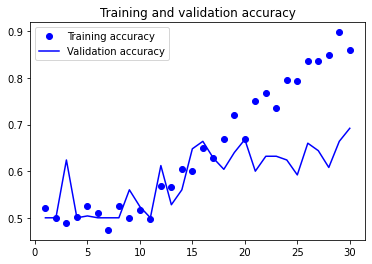

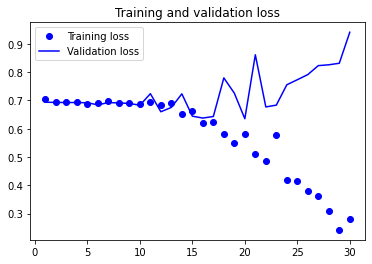

In [ ]:
#VISUALIZING RESULTS
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
#EVALUATION 1: 0.6440
results = model.evaluate(test_dataset)
print(f"Test accuracy: ", results)

8/8 [==============================] - 1s 111ms/step - loss: 1.0451 - accuracy: 0.6440
Test accuracy:  [1.0450555086135864, 0.6439999938011169]


In [ ]:
#NEW MODEL w/ DATA AUGMENTATION
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
        layers.RandomTranslation(height_factor=0.2, width_factor=0), #Vertical Shift
        layers.RandomTranslation(height_factor=0, width_factor=0.2) #Horizontal Shift
    ]
)

#BUILDING THE MODEL
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs) #W/ DATA AUG
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=8, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=16, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

#CONFIGURATION
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

#PATHS TO FILES
from tensorflow.keras.utils import image_dataset_from_directory
import os, shutil, pathlib

train_dataset = image_dataset_from_directory(
    "train",
    image_size=(180, 180),
    batch_size=64)
validation_dataset = image_dataset_from_directory(
    "val",
    image_size=(180, 180),
    batch_size=64)
test_dataset = image_dataset_from_directory(
    "test",
    image_size=(180, 180),
    batch_size=64)

Found 500 files belonging to 2 classes.
Found 250 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


In [ ]:
#FITTING THE MODEL
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset)

Epoch 1/30
8/8 [==============================] - 6s 554ms/step - loss: 0.7217 - accuracy: 0.4800 - val_loss: 0.6927 - val_accuracy: 0.5000
Epoch 2/30
8/8 [==============================] - 4s 488ms/step - loss: 0.6924 - accuracy: 0.5000 - val_loss: 0.6927 - val_accuracy: 0.5000
Epoch 3/30
8/8 [==============================] - 4s 493ms/step - loss: 0.7007 - accuracy: 0.4320 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 4/30
8/8 [==============================] - 4s 507ms/step - loss: 0.6938 - accuracy: 0.4740 - val_loss: 0.6909 - val_accuracy: 0.5080
Epoch 5/30
8/8 [==============================] - 4s 511ms/step - loss: 0.6927 - accuracy: 0.5260 - val_loss: 0.6860 - val_accuracy: 0.5280
Epoch 6/30
8/8 [==============================] - 4s 492ms/step - loss: 0.6893 - accuracy: 0.5400 - val_loss: 0.7231 - val_accuracy: 0.5040
Epoch 7/30
8/8 [==============================] - 4s 512ms/step - loss: 0.7048 - accuracy: 0.4900 - val_loss: 0.6877 - val_accuracy: 0.5120
Epoch 8/30
8/8 [====

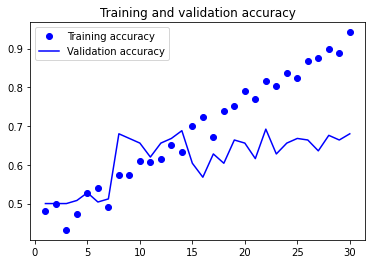

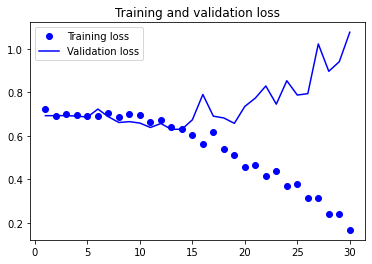

In [ ]:
#VISUALIZING RESULTS
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
#EVALUATION 2: 0.6880
results = model.evaluate(test_dataset)
print(f"Test accuracy: ", results)

8/8 [==============================] - 1s 113ms/step - loss: 0.9433 - accuracy: 0.6880
Test accuracy:  [0.9432947039604187, 0.6880000233650208]


In [ ]:
#NEW MODEL w/ DATA AUGMENTATION & DROPOUT
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
        layers.RandomTranslation(height_factor=0.2, width_factor=0), #Vertical Shift
        layers.RandomTranslation(height_factor=0, width_factor=0.2) #Horizontal Shift
    ]
)

#BUILDING THE MODEL
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs) #W/ DATA AUG
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=8, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=16, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

#CONFIGURATION
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

#PATHS TO FILES
from tensorflow.keras.utils import image_dataset_from_directory
import os, shutil, pathlib

train_dataset = image_dataset_from_directory(
    "train",
    image_size=(180, 180),
    batch_size=64)
validation_dataset = image_dataset_from_directory(
    "val",
    image_size=(180, 180),
    batch_size=64)
test_dataset = image_dataset_from_directory(
    "test",
    image_size=(180, 180),
    batch_size=64)

Found 500 files belonging to 2 classes.
Found 250 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


In [ ]:
#FITTING THE MODEL
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset)

Epoch 1/30
8/8 [==============================] - 6s 515ms/step - loss: 0.6945 - accuracy: 0.5140 - val_loss: 0.6945 - val_accuracy: 0.5000
Epoch 2/30
8/8 [==============================] - 4s 485ms/step - loss: 0.6939 - accuracy: 0.5000 - val_loss: 0.6914 - val_accuracy: 0.5000
Epoch 3/30
8/8 [==============================] - 4s 487ms/step - loss: 0.6979 - accuracy: 0.4880 - val_loss: 0.6929 - val_accuracy: 0.5040
Epoch 4/30
8/8 [==============================] - 4s 499ms/step - loss: 0.6938 - accuracy: 0.5080 - val_loss: 0.6885 - val_accuracy: 0.5040
Epoch 5/30
8/8 [==============================] - 4s 502ms/step - loss: 0.6894 - accuracy: 0.5400 - val_loss: 0.6958 - val_accuracy: 0.5600
Epoch 6/30
8/8 [==============================] - 4s 481ms/step - loss: 0.6908 - accuracy: 0.5140 - val_loss: 0.7309 - val_accuracy: 0.5400
Epoch 7/30
8/8 [==============================] - 4s 481ms/step - loss: 0.6772 - accuracy: 0.5960 - val_loss: 0.6959 - val_accuracy: 0.5880
Epoch 8/30
8/8 [====

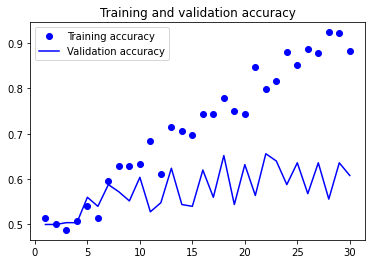

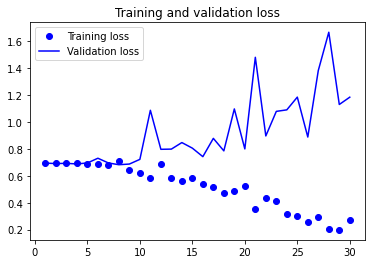

In [ ]:
#VISUALIZING RESULTS
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
#EVALUATION 3: 0.6600
results = model.evaluate(test_dataset)
print(f"Test accuracy: ", results)

8/8 [==============================] - 1s 108ms/step - loss: 0.9944 - accuracy: 0.6600
Test accuracy:  [0.9944452047348022, 0.6600000262260437]


In [ ]:



#TASK 2




In [ ]:
#INSTANTIATE VGG16
from tensorflow import keras
from tensorflow.keras import layers
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))

58900480/58889256 [==============================] - 5s 0us/step


In [ ]:
#PATHS TO FILES
from tensorflow.keras.utils import image_dataset_from_directory
import os, shutil, pathlib

current_dir = os.getcwd()
train_dir = os.path.join(current_dir, "train")
val_dir = os.path.join(current_dir, "val")
test_dir = os.path.join(current_dir, "test")

train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=(180, 180),
    batch_size=64)
validation_dataset = image_dataset_from_directory(
    val_dir,
    image_size=(180, 180),
    batch_size=64)
test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=(180, 180),
    batch_size=64)

Found 500 files belonging to 2 classes.
Found 250 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


In [ ]:
#EXTRACT LABELS
import numpy as np

def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels =  get_features_and_labels(train_dataset)
val_features, val_labels =  get_features_and_labels(validation_dataset)
test_features, test_labels =  get_features_and_labels(test_dataset)

In [ ]:
#TRAIN W/O DATA AUG
inputs = keras.Input(shape=(5, 5, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
      filepath="feature_extraction.keras",
      save_best_only=True,
      monitor="val_loss")
]
history = model.fit(
    train_features, train_labels,
    epochs=30,
    validation_data=(val_features, val_labels),
    callbacks=callbacks)

Epoch 1/30
16/16 [==============================] - 2s 99ms/step - loss: 42.9289 - accuracy: 0.8620 - val_loss: 7.9156 - val_accuracy: 0.9440
Epoch 2/30
16/16 [==============================] - 1s 62ms/step - loss: 2.8885 - accuracy: 0.9820 - val_loss: 4.2455 - val_accuracy: 0.9600
Epoch 3/30
16/16 [==============================] - 0s 27ms/step - loss: 0.5941 - accuracy: 0.9920 - val_loss: 6.4209 - val_accuracy: 0.9400
Epoch 4/30
16/16 [==============================] - 0s 28ms/step - loss: 1.7888 - accuracy: 0.9800 - val_loss: 12.5214 - val_accuracy: 0.9560
Epoch 5/30
16/16 [==============================] - 1s 61ms/step - loss: 1.0180 - accuracy: 0.9940 - val_loss: 4.0359 - val_accuracy: 0.9760
Epoch 6/30
16/16 [==============================] - 0s 30ms/step - loss: 0.1446 - accuracy: 0.9960 - val_loss: 4.4236 - val_accuracy: 0.9680
Epoch 7/30
16/16 [==============================] - 0s 28ms/step - loss: 2.1515e-25 - accuracy: 1.0000 - val_loss: 4.4236 - val_accuracy: 0.9680
Epoch 8

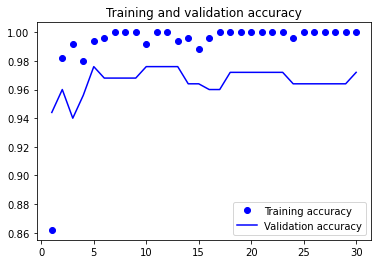

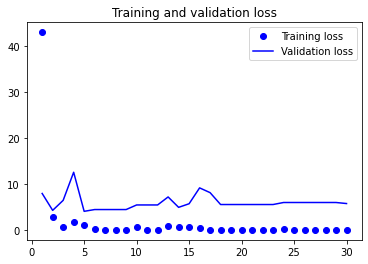

In [ ]:
#GRAPH RESULTS
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
#EVALUATION 4: TEST ACCURACY : 0.9540
test_model = keras.models.load_model(
    "feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

16/16 [==============================] - 0s 8ms/step - loss: 9.3689 - accuracy: 0.9540
Test accuracy: 0.954


In [ ]:
#NEW MODEL W/ DATA AUG
from tensorflow import keras
from tensorflow.keras import layers
conv_base  = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.trainable = False

In [ ]:
#PATHS TO FILES
from tensorflow.keras.utils import image_dataset_from_directory
import os, shutil, pathlib

current_dir = os.getcwd()
train_dir = os.path.join(current_dir, "train")
val_dir = os.path.join(current_dir, "val")
test_dir = os.path.join(current_dir, "test")

train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=(180, 180),
    batch_size=64)
validation_dataset = image_dataset_from_directory(
    val_dir,
    image_size=(180, 180),
    batch_size=64)
test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=(180, 180),
    batch_size=64)

Found 500 files belonging to 2 classes.
Found 250 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


In [ ]:
#INITIALIZING THE MODEL W/ DATA AUG
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [ ]:
#FITTING THE MODEL
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
8/8 [==============================] - 50s 6s/step - loss: 79.0366 - accuracy: 0.7540 - val_loss: 9.5220 - val_accuracy: 0.9480
Epoch 2/30
8/8 [==============================] - 48s 6s/step - loss: 3.2744 - accuracy: 0.9740 - val_loss: 8.3606 - val_accuracy: 0.9440
Epoch 3/30
8/8 [==============================] - 44s 6s/step - loss: 4.1286 - accuracy: 0.9500 - val_loss: 14.0866 - val_accuracy: 0.9520
Epoch 4/30
8/8 [==============================] - 35s 5s/step - loss: 3.3744 - accuracy: 0.9660 - val_loss: 5.9093 - val_accuracy: 0.9760
Epoch 5/30
8/8 [==============================] - 34s 4s/step - loss: 1.1369 - accuracy: 0.9840 - val_loss: 6.4410 - val_accuracy: 0.9680
Epoch 6/30
8/8 [==============================] - 34s 4s/step - loss: 8.2785 - accuracy: 0.9320 - val_loss: 10.2695 - val_accuracy: 0.9640
Epoch 7/30
8/8 [==============================] - 35s 5s/step - loss: 3.0787 - accuracy: 0.9720 - val_loss: 4.5089 - val_accuracy: 0.9840
Epoch 8/30
8/8 [===============

In [ ]:
#EVALUATION 5: TEST ACCURACY: 0.9600
test_model = keras.models.load_model(
    "feature_extraction_with_data_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

8/8 [==============================] - 23s 3s/step - loss: 5.2996 - accuracy: 0.9600
Test accuracy: 0.960


In [ ]:



#TASK 3




In [ ]:
#FREEZE LAYERS
from tensorflow import keras
from tensorflow.keras import layers
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

In [ ]:
#PATHS TO FILES
from tensorflow.keras.utils import image_dataset_from_directory
import os, shutil, pathlib

current_dir = os.getcwd()
train_dir = os.path.join(current_dir, "train")
val_dir = os.path.join(current_dir, "val")
test_dir = os.path.join(current_dir, "test")

train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=(180, 180),
    batch_size=64)
validation_dataset = image_dataset_from_directory(
    val_dir,
    image_size=(180, 180),
    batch_size=64)
test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=(180, 180),
    batch_size=64)

Found 500 files belonging to 2 classes.
Found 250 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


In [ ]:
#FITTING THE MODEL
model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
8/8 [==============================] - 43s 5s/step - loss: 0.1351 - accuracy: 0.9960 - val_loss: 3.5295 - val_accuracy: 0.9840
Epoch 2/30
8/8 [==============================] - 42s 5s/step - loss: 4.0542e-15 - accuracy: 1.0000 - val_loss: 3.5295 - val_accuracy: 0.9840
Epoch 3/30
8/8 [==============================] - 43s 6s/step - loss: 1.3929e-21 - accuracy: 1.0000 - val_loss: 3.5295 - val_accuracy: 0.9840
Epoch 4/30
8/8 [==============================] - 56s 7s/step - loss: 0.2355 - accuracy: 0.9940 - val_loss: 3.0346 - val_accuracy: 0.9760
Epoch 5/30
8/8 [==============================] - 56s 7s/step - loss: 0.5795 - accuracy: 0.9940 - val_loss: 2.7388 - val_accuracy: 0.9800
Epoch 6/30
8/8 [==============================] - 53s 7s/step - loss: 0.4615 - accuracy: 0.9900 - val_loss: 3.2421 - val_accuracy: 0.9760
Epoch 7/30
8/8 [==============================] - 53s 7s/step - loss: 0.4821 - accuracy: 0.9960 - val_loss: 3.1227 - val_accuracy: 0.9800
Epoch 8/30
8/8 [==========

In [ ]:
#EVALUATION 6: TEST ACCURACY: 0.9600
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

8/8 [==============================] - 30s 4s/step - loss: 9.7377 - accuracy: 0.9600
Test accuracy: 0.960


In [ ]:
#MODEL TEST ACCURACY RESULTS:
#EVALUATION 1: 0.6440
#EVALUATION 2: 0.6880
#EVALUATION 3: 0.6600
#EVALUATION 4: 0.9540
#EVALUATION 5: 0.9600
#EVALUATION 6: 0.9600